# Inversión Cinemática: Terremoto de Copiapó (06-06-2025)

Este notebook realiza la inversión utilizando los parametros configurandolos desde el mismo codigo.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import os
from obspy import UTCDateTime
import kdellipspy as kde

In [4]:
cfg = kde.ConfigParser()
print([i for i in dir(cfg) if not i.startswith("_")])

['ellipse', 'fault_plane', 'filepath', 'from_dict', 'get_base_template_path', 'inversion_params', 'inversion_process', 'moment_tensor', 'observed_data', 'parse', 'plot_stations', 'save', 'source_position', 'stations', 'update_stations', 'update_stations_from_sac', 'velocity_model']


## 1. Visualización Previa de SAC Files

Antes de procesar los archivos para la inversión, visualizamos las estaciones disponibles en la carpeta `RAW` usando el nuevo método del `DataPreprocessor`.

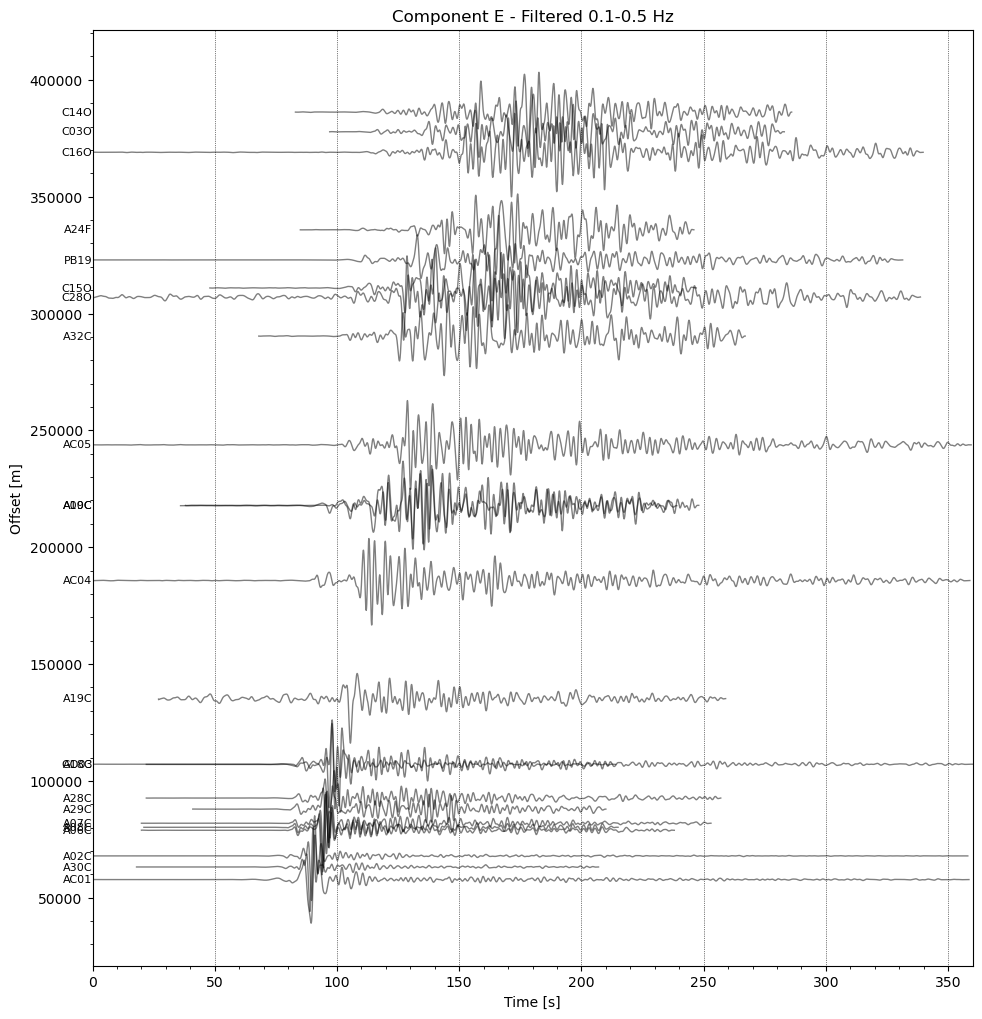

In [12]:
preprocessor = kde.DataPreprocessor(cfg)
raw_sac_dir = input_ctl.parent / "RAW" / "VELOCITY"

# Visualizar las componentes verticales filtradas entre 0.05 y 0.2 Hz
preprocessor.plot_record_section(
    raw_dir=raw_sac_dir,
    freqmin=0.1,
    freqmax=0.5,
    components=['E'],
    scale=2.0
)

✓ Configuration surgically updated: /home/alex/KDEllipsPy/inversions/copiapo-06-06-2025/input.ctl
Estaciones después de leer desde SAC: 8
 - AC01: Lat -26.148000717163086, Lon -70.5989990234375, Alt 0.0
 - A02C: Lat -27.104000091552734, Lon -70.8489990234375, Alt 0.0
 - A29C: Lat -27.422000885009766, Lon -70.26000213623047, Alt 0.0
 - AC04: Lat -28.204999923706055, Lon -71.0739974975586, Alt 0.0
 - AC05: Lat -28.836000442504883, Lon -70.27400207519531, Alt 0.0
 - A32C: Lat -29.101999282836914, Lon -71.41000366210938, Alt 0.0
 - PB19: Lat -23.905000686645508, Lon -69.29100036621094, Alt 0.0
 - C16O: Lat -29.878999710083008, Lon -71.27100372314453, Alt 0.0


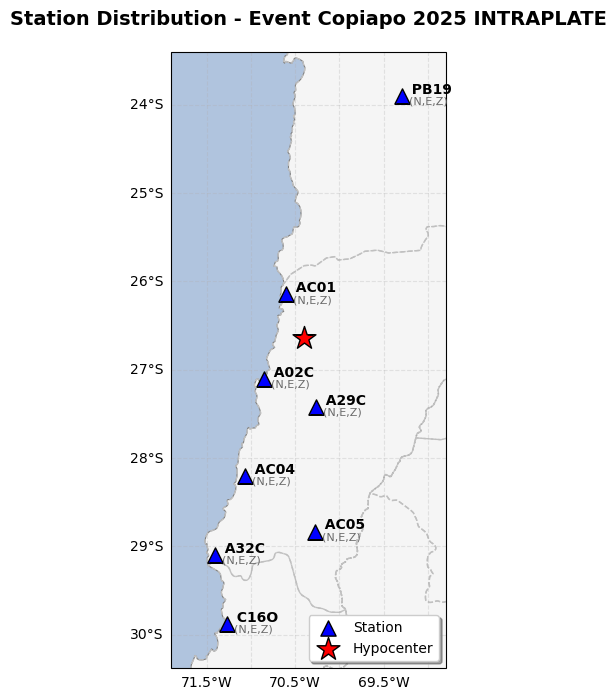

(<Figure size 1000x800 with 1 Axes>,
 <GeoAxes: title={'center': 'Station Distribution - Event Copiapo 2025 INTRAPLATE'}>)

In [14]:
# Actualizar las estaciones seleccionadas leyendo las coordenadas directamente desde los archivos SAC
estaciones_seleccionadas = ['AC01','A02C','A29C','AC04','AC05','A32C','PB19','C16O']
raw_dir = input_ctl.parent / "RAW" / "VELOCITY"
cfg.update_stations_from_sac(raw_dir=raw_dir, station_names=estaciones_seleccionadas)
print(f"Estaciones después de leer desde SAC: {len(cfg.stations.stations)}")
for s in cfg.stations.stations:
    print(f" - {s.name}: Lat {s.latitude}, Lon {s.longitude}, Alt {s.height}")
cfg.plot_stations()

## 2. Pre-procesamiento con Ventana de Tiempo y Padding

Definimos una ventana de tiempo explícita usando `UTCDateTime`. Si los datos crudos son más cortos, se rellenarán con ceros para cumplir con el `npts` requerido.

In [15]:
raw_dir = input_ctl.parent / "RAW" / "VELOCITY"
output_dir = input_ctl.parent / "DATA_PROCESSED"

# Tiempo de origen del terremoto (definido en input.ctl)
origin_time = UTCDateTime(cfg.source_position.origin_time)
print(f"Tiempo de origen: {origin_time}")
t_end = origin_time + 128.0

# Procesar trazas: recortar y aplicar zero-padding si es necesario.
# Asumimos que los archivos en 'DATA' comienzan en el origin_time (data_start_time=origin_time).
processed_data = preprocessor.process_raw_files(
    raw_dir=raw_dir,
    output_dir=output_dir,
    freq1=0.1,
    freq2=0.5,
    t_start=origin_time,    
    t_end=t_end,
    data_start_time=origin_time,
    units=2, # 2: vel (m/s)
    station_names=estaciones_seleccionadas # Opcional: filtrar estaciones
)

Tiempo de origen: 2025-06-06T17:15:06.000000Z
[signal_utils] WARNING: no instrument inventory found in DATA/RAW; response removal skipped.
✓ Saved: /home/alex/KDEllipsPy/inversions/copiapo-06-06-2025/DATA_PROCESSED/real_vel_x (npts=512)
✓ Saved: /home/alex/KDEllipsPy/inversions/copiapo-06-06-2025/DATA_PROCESSED/real_vel_y (npts=512)
✓ Saved: /home/alex/KDEllipsPy/inversions/copiapo-06-06-2025/DATA_PROCESSED/real_vel_z (npts=512)


## 3. Record Section (Validación Visual de Datos Procesados)

Visualizamos el Record Section de los datos ya procesados para verificar que el padding y el filtrado sean correctos.

In [19]:
time = np.arange(cfg.observed_data.npts) * cfg.observed_data.delta
sta_names = [s.name for s in cfg.stations.stations]

## 4. Inversión Neighbourhood Algorithm (NA)

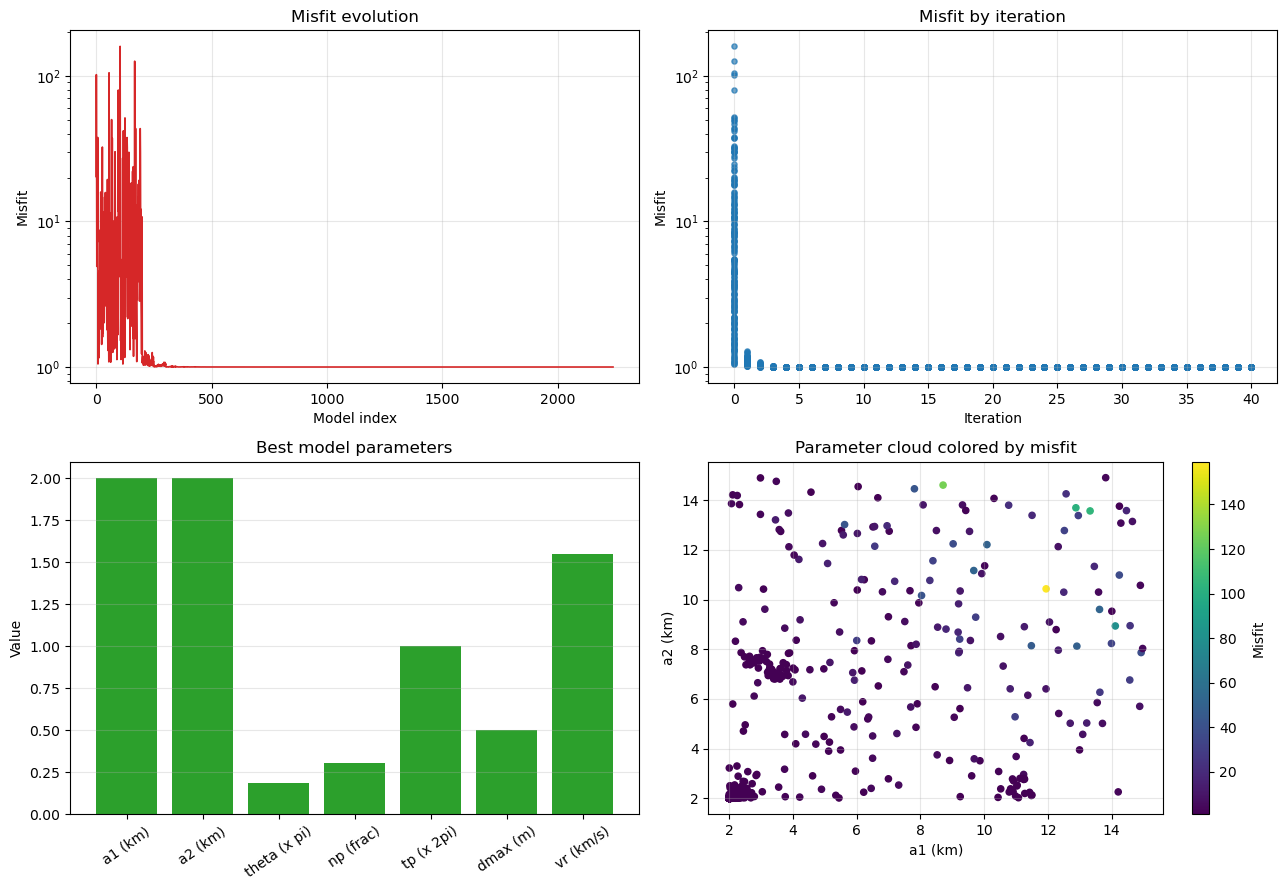

✓ Gráfico guardado: /home/alex/KDEllipsPy/inversions/copiapo-06-06-2025/Figures/Figures/NA_parameter_convergence.png


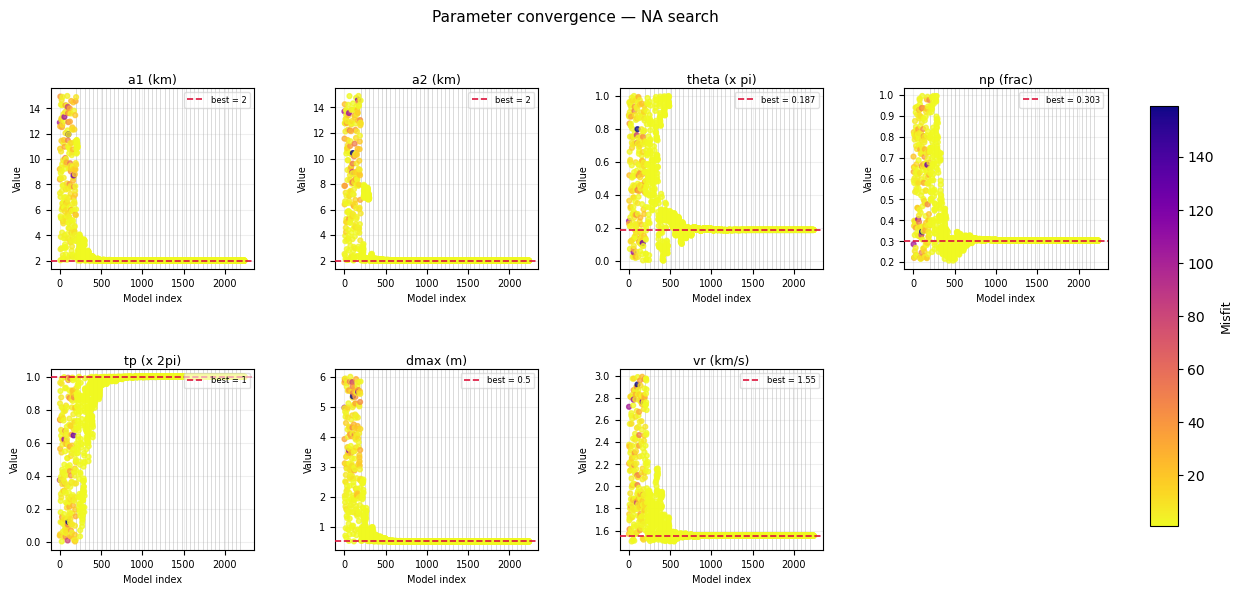

In [8]:
os.makedirs('./output', exist_ok=True)
result.save('./output/inversion_result.joblib')
result.plot(show=True, save_path='./output/na_results.png')
result.plot_convergence(show=True, save_path='./output/parameter_convergence.png')
result.plot_fit(show=True, save_path='./output/waveform_fit.png')